# Imports

In [1]:
import src.viz as viz
import src.sim as sim
import src.analysis as ana
import src.io_utils as io
import pandas as pd
import src.analysis_classes as ana_cls




path = "data/health_study_dataset.csv"
loader = io.Load_CSV_To_DataFrame(path)
df =loader.df
var_disease_simulation_summary = ana.disease_simulation_summary(loader)



## Introduction 

I denna analys undersöks ett hälsodataset med variabler som ålder,vikt,länged,systoliskt blodtryck, koesteralnivå samt rökstatus. 

Syftet är att:
- Beräkna beskrivande statistik (medelvärde, median, min, max)
- Skapa diagram för centrala variabler från ålder, vikt etc
- Beräkna andelen personer sjuka
- Genomföra simuleringar av t.ex. Sjukdomförekomster
- Beräkna konfidensintervall via två metoder med motevering till varför
- Testa hypotesen: *“Rökare har högre systoliskt blodtryck än icke-rökare”*

## Beskrivande statistik

Här visas medelvärdet, medain,min och max för de fem centrala variabler i datasetet.

In [2]:
print(ana.summarize_decriptic_statistics(loader))

               mean  median    min     max
age           49.43   50.00   18.0   90.00
weight        73.41   73.20   33.7  114.40
height       171.85  171.35  144.4  200.40
systolic_bp  149.18  149.40  106.8  185.90
cholesterol    4.93    4.97    2.5    7.88


### Histogram av systoliskt blodtryck
Histogrammet visar fördelningen av systoliskt blodtryck. Vi ser att blodtrycket är lite högt. Enligt 1177.se ska blodtrycket ligga 140. men man kan se att dem största topprna är över 140.


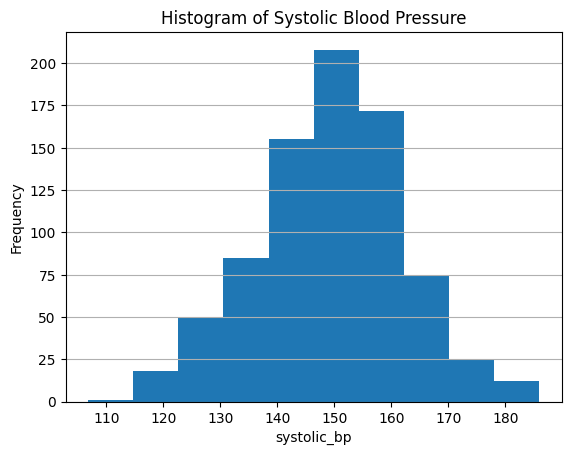

In [3]:
viz.histogram(df,"systolic_bp","Systolic Blood Pressure")

*Kommentar:* Fördelningen är relativt nomralfördelad men är lite skev åt höger

### Boxgram av vikt mot kön
Boxgram visar fördelningen av vikt vs kön. Vi ser att medelvärdet för män är runt 80 kg men sprider sig mer up än ner. Män har också den största outliern med över 110 kg. 

Längden dessa män måste vara runt för att denna vikt runt sammlade spridningen ska vara för att få ett helsosam bmi är runt 190 cm enligt ViktVäktrana. Detta är väldigt osannolikt så vi kan ut gå då från att dem är övervikgt. (blodtrycket stärket detta även fall om det är blandat kön)


För kvinor är runt 70 kg men sprider sig neråt och har den minsta outliern på mindre än 40 kg. 

Samma argument som ovan dessa kvinor måste vara över 170 cm för att deras vikt ska vara helsosamma enligt ViktVäkktrana. Vilket är inte sannolikt. 

Att alla som gick ignom denna undersökingen är över medelvärdet för kroppslängged 180 cm för män, 166 cm för kvinnor 2016-2017 enligt scb.se är inte sannolikt


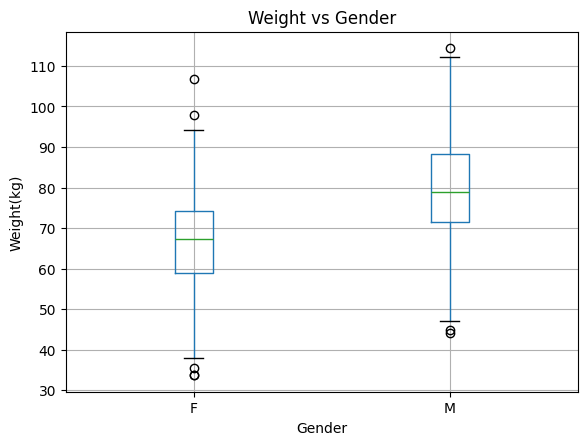

In [4]:
viz.box(df,"weight","sex","Weight vs Gender","Gender","Weight(kg)")


### Stapeldiagram av rökare, ikke rökare



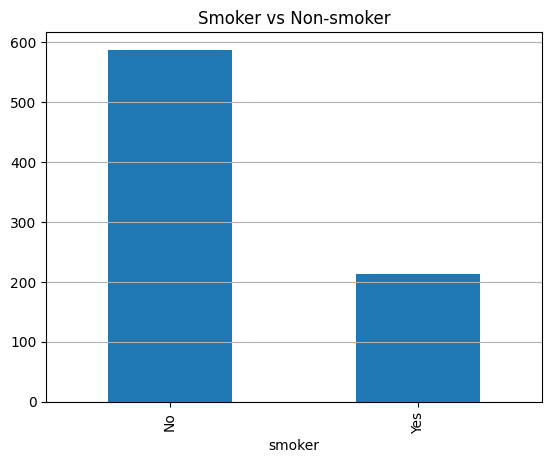

In [5]:
viz.count_vaule_bar(df,"smoker","Smoker vs Non-smoker")


*Kommentar:* stor andel inte rökare

## Simulering av sjukdomsförekomst
Här simuleras 1000 personer baserat på den observerade sannolikheten att ha sjukdomen.

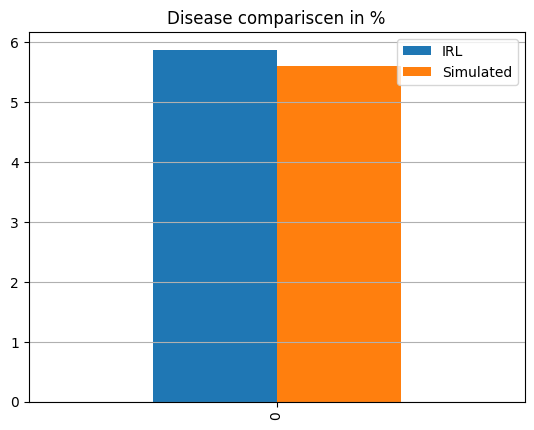

           IRL (%)  Sim (%)
Inte sjuk    94.12     94.4
Sjuk          5.88      5.6


In [6]:

ana_cls.DiseaseSimulator(loader.df).bar_chart("Disease compariscen in %")
print(var_disease_simulation_summary)



*Kommentar:* för seed 42 så är simulation någon grad mindre chans att bli sjuk men inte tillräkligt stor förändring för att det ska påvärka resultaten för mycket

## Konfidensintervall (Normalapproximation)

Normalapproximation används för att beräkna ett 95% konfidensintervall för medelvärdet av systoliskt blodtryck.
Eftersom stickprovsstorleken är stor kan vi enligt centrala gränsvärdessatsen anta att stickprovsmedelvärdet är
ungefär normalfördelat.

Källa:
Marina Axelson-Fisk (2016). Normalfördelning, Centrala 
gränsvärdessatsen, normalapproximation.
Chalmers tekniska högskola, Föreläsning 4, kapitel 4.
(Se särskilt sida 10–11.)
https://www.math.chalmers.se/Stat/Grundutb/CTH/tms063/1516/matstat_f4_tms063.pdf

In [7]:
print(f"Lower: {ana.summarize_confidence_interval(loader,df,"systolic_bp")[0]} \nHigher: {ana.summarize_confidence_interval(loader,df,"systolic_bp")[1]} \nMean: {ana.summarize_confidence_interval(loader,df,"systolic_bp")[2]}")


Lower: 148.29 
Higher: 150.07 
Mean: 149.18


## Hypotesprövning

**Hypotes:**  
- Hypotes 1: Rökare har *inte* högre medel-blodtryck än icke-rökare.  
- Hypotes 2 : Rökare har *högre* medel-blodtryck än icke-rökare.

Vi genomförde ett ensidigt t-test med funktionen `ttest_ind` från SciPy. Testet jämförde det genomsnittliga
systoliska blodtrycket mellan rökare och icke-rökare i datasetet.



In [8]:
print(f"p vaule: {(ana.t_test(df,"smoker","systolic_bp")[1]*100).round(2)}% \nt värde. {ana.t_test(df,"smoker","systolic_bp")[0].round(2)}")

p vaule: 32.25% 
t värde. 0.46


### Resulat
Eftersom p-värdet överstiger 5% finns det inte tillräckligt med statistiskt stöd för att förkasta Hypotes_1. Den observerade skillnaden kan alltså förklaras av slumpen.

Källa till anledning 5%:
Marina Axelson-Fisk (2016). Normalfördelning, Centrala 
gränsvärdessatsen, normalapproximation.
Chalmers tekniska högskola, Föreläsning 4, kapitel 4.
(Se särskilt sida 18.)
https://www.math.chalmers.se/Stat/Grundutb/CTH/tms063/1516/matstat_f4_tms063.pdf


### Linjär regression av systoliskt blodtryck

För att undersöka sambandet mellan ålder, vikt och systoliskt blodtryck
genomfördes en linjär regression med hjälp av scikit-learn. Modellen
försöker förutsäga blodtrycket utifrån två variabler:

- `age`  
- `weight`  

Modellen får då formen:

$$

\hat{y} = b_0 + b_1 \cdot \text{age} + b_2 \cdot \text{avg weight}

$$

där:

- \(b_0\) är interceptet  
- \(b_1\) är ökningen i blodtryck per ökad ålder  
- \(b_2\) är ökningen i blodtryck per ökad vikt  

### Visualisering av regressionen

Eftersom modellen har två oberoende variabler (ålder och vikt) går det
inte att rita ett vanligt 2D-plan direkt. För att visualisera sambandet
mellan **ålder och blodtryck** håller vi därför vikten konstant på
medelvärdet i datasetet. På så sätt kan vi rita en linje som visar hur
modellen predikterar blodtryck när endast åldern förändras.

Den svarta linjen i diagrammet visar modellens prediktioner:

$$

\hat{y} = b_0 + b_1 \cdot \text{age} + b_2 \cdot \text{avg weight}

$$

### Tolkning

Scatterploten visar de verkliga datapunkterna, medan den svarta
regressionslinjen visar den trend som modellen lär sig. Linjen lutar
svagt uppåt, vilket indikerar att systoliskt blodtryck tenderar att
öka med åldern när vikten hålls konstant. Detta stämmer överens med
förväntade medicinska samband och bekräftar att regression är en rimlig
analysmetod för denna typ av data. källa till medicinska samband https://www.ncbi.nlm.nih.gov/books/NBK537297/?utm_source=chatgpt.com


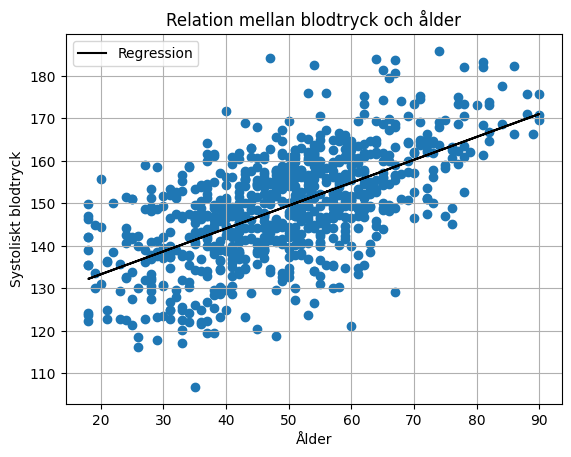

    Intercept  Slope_age  Slope_weight        r2  pred_50,70
0  109.499081   0.538928      0.177658  0.405256   148.88149


In [11]:
RL = ana.linijer_regresion(loader.df,"age","weight","systolic_bp")
viz.scater(RL,loader.df,"age","systolic_bp","weight")
print(pd.DataFrame(RL))